# 01 Conceitos Iniciais - Prática em Python

Este notebook concentra a parte operacional da aula: geração de amostras e comparação entre planos amostrais com Pandas.

## 1) Carregamento de dados

Amostras podem ser geradas por meio da biblioteca Pandas no Python. Em particular, a função [`sample`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sample.html) permite gerar amostras aleatórias de acordo com diferentes planos amostrais.

Para ilustrar, vamos usar um conjunto de dados de avistamentos de OVNIs (Kaggle/NUFORC). Alguns atributos relevantes:

- `datetime`: momento do avistamento (MM/DD/AAAA HH:mm)
- `city`: localização do avistamento
- `state`: estado do avistamento
- `country`: país do avistamento
- `shape`: formato observado

Para reprodutibilidade, fixamos uma semente (`RANDOM_STATE`).

In [34]:
import numpy as np
import pandas as pd

RANDOM_STATE = 42

link = '../data/scrubbed.csv'

ufo_df = pd.read_csv(link, encoding="utf8", low_memory=False)

# força numérico; valores inválidos viram NaN
# inspecionar nomes reais
print(ufo_df.columns.tolist())

# normalizar nomes de coluna
ufo_df.columns = (
    ufo_df.columns
    .str.strip()          # remove espaços no início/fim
    .str.lower()          # caixa baixa
)

# agora converte com segurança
ufo_df["latitude"] = pd.to_numeric(ufo_df["latitude"], errors="coerce")
ufo_df["longitude"] = pd.to_numeric(ufo_df["longitude"], errors="coerce")

ufo_df.head(12)

['datetime', 'city', 'state', 'country', 'shape', 'duration (seconds)', 'duration (hours/min)', 'comments', 'date posted', 'latitude', 'longitude ']


,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
0,10/10/1949 20:30,san marcos,tx,us,cylinder,2700,45 minutes,This event took place in early fall around 194...,4/27/2004,29.883056,-97.941111
1,10/10/1949 21:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.384210,-98.581082
2,10/10/1955 17:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.200000,-2.916667
3,10/10/1956 21:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.978333,-96.645833
4,10/10/1960 20:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.418056,-157.803611
5,10/10/1961 19:00,bristol,tn,us,sphere,300,5 minutes,My father is now 89 my brother 52 the girl wit...,4/27/2007,36.595000,-82.188889
6,10/10/1965 21:00,penarth (uk/wales),NaN,gb,circle,180,about 3 mins,penarth uk circle 3mins stayed 30ft above m...,2/14/2006,51.434722,-3.180000
7,10/10/1965 23:45,norwalk,ct,us,disk,1200,20 minutes,A bright orange color changing to reddish colo...,10/2/1999,41.117500,-73.408333
8,10/10/1966 20:00,pell city,al,us,disk,180,3 minutes,Strobe Lighted disk shape object observed clos...,3/19/2009,33.586111,-86.286111
9,10/10/1966 21:00,live oak,fl,us,disk,120,several minutes,Saucer zaps energy from powerline as my pregna...,5/11/2005,30.294722,-82.984167


## 2) Inspeção inicial do dataset

Podemos primeiro inspecionar os detalhes dos atributos desse conjunto de dados.

Antes de comparar planos amostrais por `country`, vamos restringir a análise a registros com país informado. A partir desse ponto, a "população" do exercício passa a ser esse subconjunto.

In [35]:
ufo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80332 entries, 0 to 80331
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   datetime              80332 non-null  object 
 1   city                  80332 non-null  object 
 2   state                 74535 non-null  object 
 3   country               70662 non-null  object 
 4   shape                 78400 non-null  object 
 5   duration (seconds)    80332 non-null  object 
 6   duration (hours/min)  80332 non-null  object 
 7   comments              80317 non-null  object 
 8   date posted           80332 non-null  object 
 9   latitude              80331 non-null  float64
 10  longitude             80332 non-null  float64
dtypes: float64(2), object(9)
memory usage: 6.7+ MB


In [36]:
ufo_df.shape

(80332, 11)

In [ ]:
# manter apenas registros com país informado (população de análise deste notebook)
ufo_df = ufo_df[ufo_df["country"].notna() & (ufo_df["country"].str.strip() != "")]
print('População de análise (country válido):', len(ufo_df))

In [38]:
ufo_df.shape

(70662, 11)

## 3) Amostragem sistemática

Agora vamos gerar uma amostra sistemática com ponto inicial aleatório e tamanho final controlado (`n = 100`).

Observação: a amostragem sistemática depende da ordem da base; se houver padrão periódico na ordenação, pode haver viés.

In [ ]:
n = 100

# passo sistemático k escolhido para produzir aproximadamente n observações
k = max(1, len(ufo_df) // n)
rng = np.random.default_rng(RANDOM_STATE)
inicio = int(rng.integers(0, k))

# amostragem sistemática: início aleatório + passo fixo
amostra_sistematica = ufo_df.iloc[inicio::k].head(n).copy()

print(f"Total da população: {len(ufo_df)}")
print(f"k = {k}, início = {inicio}")
print(f"Tamanho da amostra sistemática: {len(amostra_sistematica)}")

amostra_sistematica.head()

## 4) Amostragem aleatória simples

Agora retiramos uma amostra aleatória simples de tamanho `100` com semente fixa para reprodução.

In [40]:
amostra_aas = ufo_df.sample(n=100, random_state=RANDOM_STATE)
amostra_aas.head()

,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
32639,3/20/2014 19:00,patterson,la,us,other,180,3 minutes,A single craft of unique shape moving very fas...,4/4/2014,29.693056,-91.301944
38855,4/24/2008 16:45,acton,ca,us,unknown,15,15 sec,Bad weather and overcast skies make a great pl...,7/28/2010,34.470000,-118.195833
54778,7/10/2009 00:05,addingham (uk/england),NaN,gb,light,180,3 minutes,Vivid ufo sighting in Addingham&#44 West Yorks...,8/5/2009,53.933333,-1.883333
71655,8/5/2007 22:00,ozark,mo,us,light,120,2 min,reddish light that moved slowly across night s...,10/8/2007,37.020833,-93.205833
14267,11/3/2013 18:50,parma,oh,us,fireball,120,couple mind,Orange ball dripping smaller balls and disappe...,11/11/2013,41.404722,-81.723056


In [41]:
amostra_aas.shape

(100, 11)

## 5) Distribuição da população e amostra estratificada

Vamos produzir uma amostra estratificada considerando o atributo `country` e comparar proporções entre população e amostra.

Text(0, 0.5, 'Proporção')

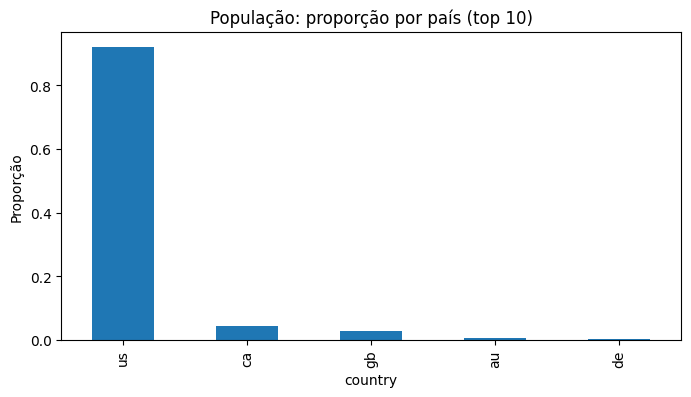

In [42]:
# proporções por país na população (top 10)
prop_pop = ufo_df['country'].value_counts(normalize=True, dropna=False)

ax = prop_pop.head(10).sort_values(ascending=False).plot(
    kind='bar', figsize=(8, 4), title='População: proporção por país (top 10)'
)
ax.set_ylabel('Proporção')

In [ ]:
# amostra estratificada proporcional por país (~10% por estrato)
# Nota: estratos muito pequenos podem ter zero observações após arredondamento implícito.
sample_df = (
    ufo_df
    .groupby('country', group_keys=False)
    .apply(lambda x: x.sample(frac=0.1, random_state=RANDOM_STATE))
    .reset_index(drop=True)
)

print(f"Tamanho da amostra estratificada: {len(sample_df)}")
print('Países na população:', ufo_df['country'].nunique())
print('Países na amostra estratificada:', sample_df['country'].nunique())
sample_df.head()

Text(0, 0.5, 'Proporção')

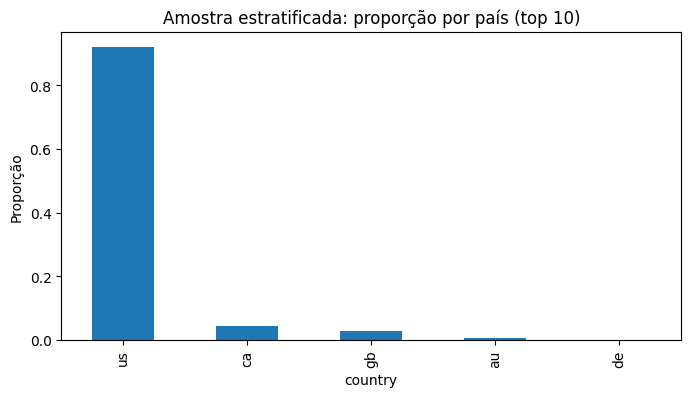

In [44]:
# proporções por país na amostra estratificada (top 10)
prop_strat = sample_df['country'].value_counts(normalize=True, dropna=False)

ax = prop_strat.head(10).sort_values(ascending=False).plot(
    kind='bar', figsize=(8, 4), title='Amostra estratificada: proporção por país (top 10)'
)
ax.set_ylabel('Proporção')

## Verificação

Agora verificamos explicitamente se as proporções por `country` na amostra estratificada estão próximas das proporções da população.

Além do erro absoluto por país, calculamos uma medida global ponderada pelo tamanho dos estratos (L1).

In [ ]:
comparacao = (
    pd.DataFrame({'pop': prop_pop, 'amostra_estrat': prop_strat})
    .fillna(0)
)
comparacao['erro_abs'] = (comparacao['pop'] - comparacao['amostra_estrat']).abs()

erro_medio_nao_ponderado = comparacao['erro_abs'].mean()
dist_l1 = comparacao['erro_abs'].sum()  # diferença global de composição

print('Erro absoluto médio (não ponderado):', round(erro_medio_nao_ponderado, 6))
print('Distância L1 global entre proporções:', round(dist_l1, 6))
print('Maiores diferenças absolutas:')
comparacao.sort_values('erro_abs', ascending=False).head(10)

## Extensão opcional: visualização espacial com Folium

A célula abaixo é complementar e não faz parte do núcleo sobre planos amostrais. Use-a apenas para explorar a distribuição geográfica dos registros com coordenadas válidas.

In [ ]:
# !pip install folium  # se necessário

import pandas as pd
import folium
from folium.plugins import MarkerCluster

# 1) Padroniza nomes de colunas e converte coordenadas
ufo_df.columns = ufo_df.columns.str.strip().str.lower()

ufo_df["latitude"] = pd.to_numeric(ufo_df["latitude"], errors="coerce")
ufo_df["longitude"] = pd.to_numeric(ufo_df["longitude"], errors="coerce")

# 2) Filtra coordenadas válidas
map_df = ufo_df.dropna(subset=["latitude", "longitude"]).copy()

# Remove pontos fora do intervalo geográfico válido
map_df = map_df[
    map_df["latitude"].between(-90, 90) &
    map_df["longitude"].between(-180, 180)
]

print(f"Total com coordenadas válidas: {len(map_df)}")

# 3) (Opcional) amostra para não sobrecarregar o mapa
MAX_POINTS = 5000
if len(map_df) > MAX_POINTS:
    map_df = map_df.sample(MAX_POINTS, random_state=42)

# 4) Centro inicial do mapa
center = [map_df["latitude"].mean(), map_df["longitude"].mean()]
m = folium.Map(location=center, zoom_start=3, tiles="CartoDB positron")

# 5) Cluster de marcadores
cluster = MarkerCluster().add_to(m)

for _, row in map_df.iterrows():
    popup_txt = (
        f"datetime: {row.get('datetime', 'NA')}<br>"
        f"city: {row.get('city', 'NA')}<br>"
        f"state: {row.get('state', 'NA')}<br>"
        f"country: {row.get('country', 'NA')}<br>"
        f"shape: {row.get('shape', 'NA')}"
    )
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=3,
        weight=1,
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(popup_txt, max_width=300)
    ).add_to(cluster)

m

# Dados i.i.d.

Neste experimento, simulamos repetidamente o cálculo da média amostral em dois cenários distintos. 
- No primeiro, todas as observações são geradas a partir da mesma distribuição Normal, ou seja, estamos repetindo exatamente o mesmo experimento probabilístico a cada ponto da amostra. 
- No segundo, metade das observações vem de uma Normal e a outra metade de uma Exponencial, o que significa que estamos misturando dois fenômenos estatísticos diferentes dentro da mesma “amostra”. 

Ao comparar os histogramas das médias obtidas nas simulações, observe como o comportamento da média muda quando deixamos de observar o mesmo processo gerador de dados. A ideia central aqui não é ainda discutir resultados assintóticos, mas perceber que, quando os dados não vêm todos da mesma distribuição, a interpretação da média amostral se torna menos clara: afinal, estamos estimando a média de qual população?


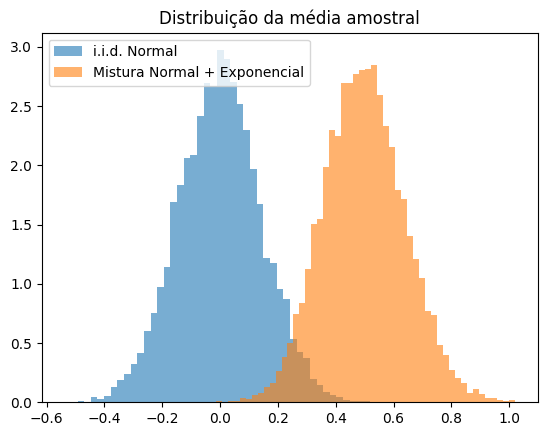

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# parâmetros
n = 50              # tamanho da amostra
n_sim = 10000       # número de simulações

# ===============================
# Caso 1: i.i.d. Normal(0,1)
# ===============================
means_iid = []

for _ in range(n_sim):
    sample = np.random.normal(loc=0, scale=1, size=n)
    means_iid.append(np.mean(sample))

means_iid = np.array(means_iid)

# ===============================
# Caso 2: NÃO identicamente distribuídas
# Metade normal, metade exponencial
# ===============================
means_mixed = []

for _ in range(n_sim):
    normal_part = np.random.normal(loc=0, scale=1, size=n//2)
    exp_part = np.random.exponential(scale=1, size=n//2)
    sample = np.concatenate([normal_part, exp_part])
    means_mixed.append(np.mean(sample))

means_mixed = np.array(means_mixed)

# ===============================
# Visualização
# ===============================
plt.hist(means_iid, bins=50, alpha=0.6, density=True, label="i.i.d. Normal")
plt.hist(means_mixed, bins=50, alpha=0.6, density=True, label="Mistura Normal + Exponencial")

plt.legend()
plt.title("Distribuição da média amostral")
plt.show()